# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

# Loading the Data

In [14]:
df = pd.read_excel('../data/raw/bank-full.xlsx', header=None)

# Split the single column into multiple columns
df = df[0].str.split(';', expand=True)

# Fix column names (remove quotes)
df.columns = df.iloc[0].str.replace('"', '')
df = df[1:]

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,"""management""","""married""","""tertiary""","""no""",2143,"""yes""","""no""","""unknown""",5,"""may""",261,1,-1,0,"""unknown""","""no"""
1,44,"""technician""","""single""","""secondary""","""no""",29,"""yes""","""no""","""unknown""",5,"""may""",151,1,-1,0,"""unknown""","""no"""
2,33,"""entrepreneur""","""married""","""secondary""","""no""",2,"""yes""","""yes""","""unknown""",5,"""may""",76,1,-1,0,"""unknown""","""no"""
3,47,"""blue-collar""","""married""","""unknown""","""no""",1506,"""yes""","""no""","""unknown""",5,"""may""",92,1,-1,0,"""unknown""","""no"""
4,33,"""unknown""","""single""","""unknown""","""no""",1,"""no""","""no""","""unknown""",5,"""may""",198,1,-1,0,"""unknown""","""no"""


# Basic Exploration

In [15]:
print("Shape:", df.shape)
df.info()

Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  object
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  object
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  object
 10  month      45211 non-null  object
 11  duration   45211 non-null  object
 12  campaign   45211 non-null  object
 13  pdays      45211 non-null  object
 14  previous   45211 non-null  object
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: object(17)
memory usage: 5.9+ MB


In [16]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,77,12,3,4,2,7168,2,2,3,31,12,1573,48,559,41,4,2
top,32,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""cellular""",20,"""may""",124,1,-1,0,"""unknown""","""no"""
freq,2085,9732,27214,23202,44396,3514,25130,37967,29285,2752,13766,188,17544,36954,36954,36959,39922


# Missing Values Check

In [17]:
df.isnull().sum()

0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

# Data Cleaning

In [18]:
df.replace('unknown', np.nan, inplace=True)

# Feature Engineering (CRITICAL)

### Age Groups

In [23]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object', name=0)

In [24]:
# Convert numeric columns
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

for col in num_cols:
    df[col] = pd.to_numeric(df[col])

In [25]:
bins = [18, 25, 35, 50, 65, 100]
labels = ['18-25', '26-35', '36-50', '51-65', '65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

### Engagement Feature (Call Quality)

In [26]:
df['engaged'] = df['duration'].apply(lambda x: 1 if x > 100 else 0)

### Contacted Feature

In [27]:
df['contacted'] = df['contact'].apply(lambda x: 0 if pd.isna(x) else 1)

### Conversion Feature

In [38]:
df['converted'] = df['y'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

In [39]:
print(df['y'].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [40]:
conversion_rate = df['converted'].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 11.70%


# Save Cleaned Data

In [41]:
df.to_csv('../data/processed/cleaned_bank_data.csv', index=False)

# 🚀 FUNNEL ANALYSIS

# Create Funnel

In [42]:
total = len(df)
contacted = df['contacted'].sum()
engaged = df['engaged'].sum()
converted = df['converted'].sum()

funnel = pd.DataFrame({
    'Stage': ['Total', 'Contacted', 'Engaged', 'Converted'],
    'Users': [total, contacted, engaged, converted]
})

funnel

,Stage,Users
0,Total,45211
1,Contacted,45211
2,Engaged,34328
3,Converted,5289


# Conversion Rates

In [43]:
funnel['Conversion Rate (%)'] = funnel['Users'].pct_change() * 100
funnel

,Stage,Users,Conversion Rate (%)
0,Total,45211,NaN
1,Contacted,45211,0.000000
2,Engaged,34328,-24.071576
3,Converted,5289,-84.592752


# Funnel Chart

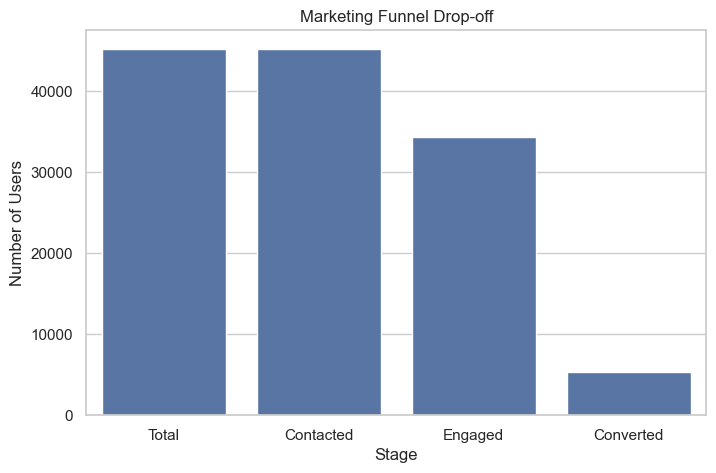

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x='Stage', y='Users', data=funnel)

plt.title('Marketing Funnel Drop-off')
plt.ylabel('Number of Users')

plt.savefig('../outputs/charts/funnel_dropoff_chart.png')
plt.show()

# 🚀 CONVERSION ANALYSIS

# Overall Conversion Rate

In [46]:
conversion_rate = df['converted'].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 11.70%


# Conversion by Job

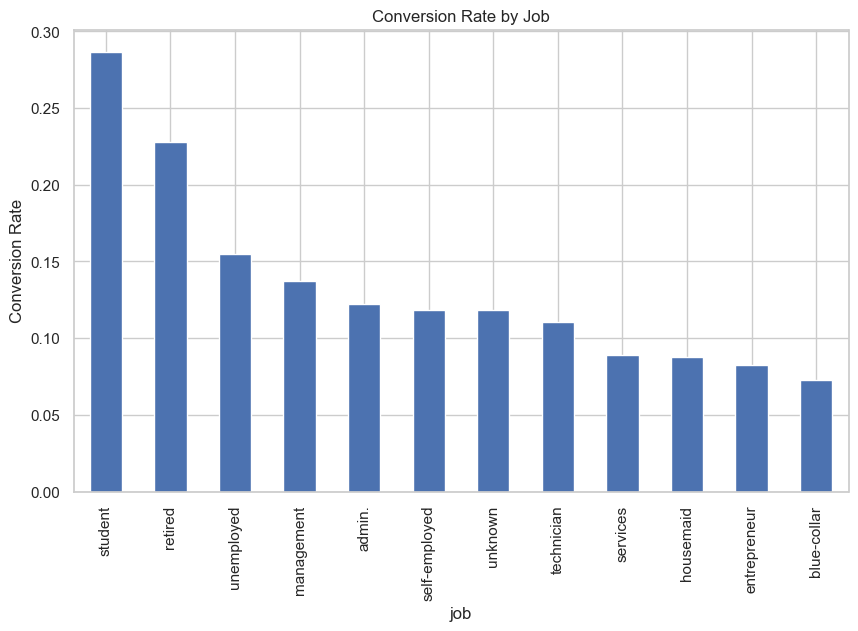

In [47]:
job_conv = df.groupby('job')['converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
job_conv.plot(kind='bar')

plt.title('Conversion Rate by Job')
plt.ylabel('Conversion Rate')

plt.savefig('../outputs/charts/jobwise_conversion.png')
plt.show()

# Conversion by Age Group

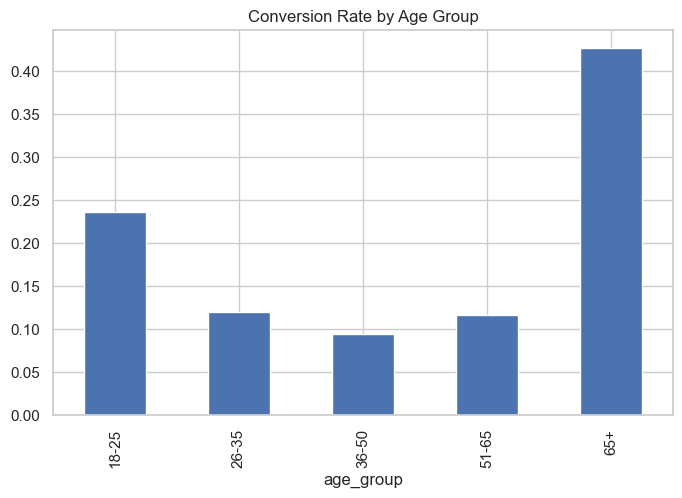

In [48]:
age_conv = df.groupby('age_group')['converted'].mean()

plt.figure(figsize=(8,5))
age_conv.plot(kind='bar')

plt.title('Conversion Rate by Age Group')

plt.savefig('../outputs/charts/age_group_analysis.png')
plt.show()

# Conversion by Contact Type

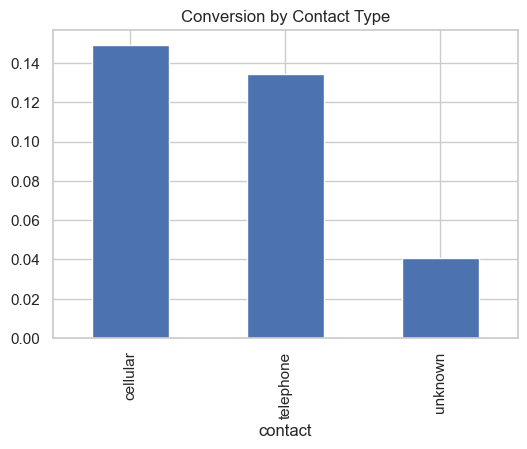

In [49]:
contact_conv = df.groupby('contact')['converted'].mean()

plt.figure(figsize=(6,4))
contact_conv.plot(kind='bar')

plt.title('Conversion by Contact Type')

plt.savefig('../outputs/charts/contact_type_analysis.png')
plt.show()

# Conversion by Month

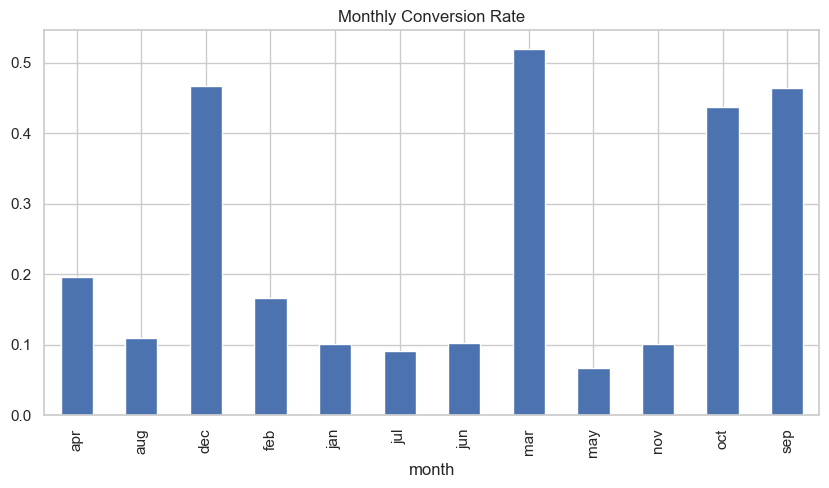

In [50]:
month_conv = df.groupby('month')['converted'].mean()

plt.figure(figsize=(10,5))
month_conv.plot(kind='bar')

plt.title('Monthly Conversion Rate')

plt.savefig('../outputs/charts/monthly_conversion.png')
plt.show()

# Campaign Performance

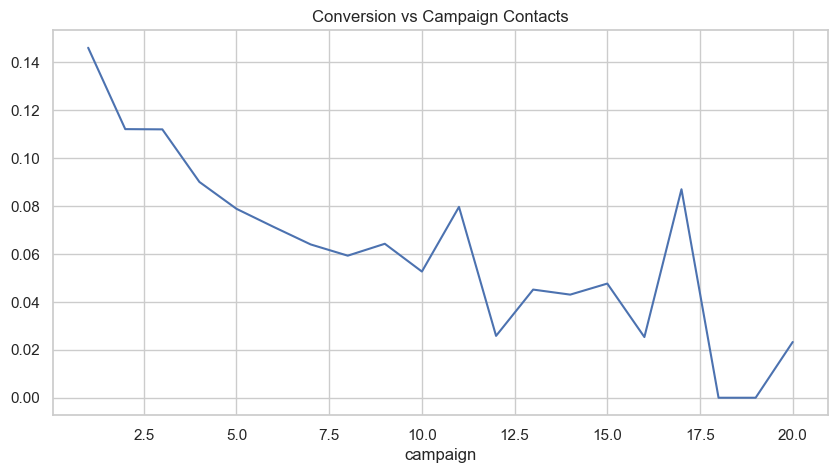

In [51]:
campaign_conv = df.groupby('campaign')['converted'].mean()

plt.figure(figsize=(10,5))
campaign_conv.head(20).plot()

plt.title('Conversion vs Campaign Contacts')

plt.savefig('../outputs/charts/campaign_performance.png')
plt.show()

# Drop-off %

In [52]:
drop_off = funnel.copy()
drop_off['Drop-Off (%)'] = 100 - drop_off['Conversion Rate (%)']

drop_off

,Stage,Users,Conversion Rate (%),Drop-Off (%)
0,Total,45211,NaN,NaN
1,Contacted,45211,0.000000,100.000000
2,Engaged,34328,-24.071576,124.071576
3,Converted,5289,-84.592752,184.592752


# Funnel Interpretation

📊 Key Insights
Large drop between Contacted → Engaged
Engagement (call duration) is the biggest factor
Some job categories convert much better
Age group influences conversion
Certain months show higher performance
Increasing campaign calls does not guarantee conversion
💡 Recommendations
Improve call quality instead of increasing quantity
Target high-converting job segments
Focus campaigns during high-performing months
Increase customer engagement strategies
Optimize contact methods (phone vs cellular)